# BioStress AI
## AI-Based Physiological Stress Analysis using HRV Data

### Author:
Valeria Martínez Ramírez

### Project Overview
This project explores the use of Heart Rate Variability (HRV) metrics and Machine Learning techniques to identify physiological patterns associated with cognitive stress conditions.

# 1. Introduction

Heart Rate Variability (HRV) is a physiological phenomenon that reflects variations in the time intervals between consecutive heartbeats. HRV analysis is widely used in biomedical research because it provides valuable information about autonomic nervous system activity and physiological stress responses.

Cognitive stress conditions such as interruptions and time pressure may alter HRV metrics, affecting cardiovascular regulation and autonomic balance. Understanding these physiological responses can contribute to the development of intelligent healthcare systems and AI-based stress monitoring technologies.

The objective of this project is to analyze HRV metrics under different cognitive stress conditions and evaluate the potential of Machine Learning models to classify physiological states using biomedical data.

# 2. Physiological Background

To understand how Machine Learning models can identify stress conditions, it is first necessary to understand the physiological signals generated by the human body, particularly those associated with cardiovascular regulation and autonomic nervous system activity.

## 2.1 What is HRV?

Heart Rate Variability (HRV) refers to the variation in time intervals between consecutive heartbeats rather than the heart rate itself (Pedraza-Rodríguez et al., 2020).

HRV is considered a non-invasive indicator of autonomic nervous system regulation and physiological adaptability. It reflects the body's ability to respond to internal and external stimuli, including cognitive and emotional stress (Pérez Linares et al., 2023).

Under healthy conditions, higher HRV is generally associated with greater physiological flexibility and resilience. In contrast, cognitive stress tends to reduce HRV, producing more rigid and less adaptable cardiovascular responses (Pedraza-Rodríguez et al., 2020).

## 2.2 The Autonomic Nervous System (ANS)

The Autonomic Nervous System (ANS) is responsible for maintaining homeostasis and regulating involuntary physiological functions such as heart rate, respiration, circulation, and metabolic activity (Bratt, 2020).

The ANS operates through two primary branches:

### Sympathetic Nervous System (SNS)

The Sympathetic Nervous System is commonly associated with the “fight or flight” response. It prepares the body to react to stress or danger by increasing heart rate, blood pressure, and energy expenditure (Bratt, 2020; Pérez Linares et al., 2023).

### Parasympathetic Nervous System (PNS)

The Parasympathetic Nervous System promotes recovery and energy conservation. Through vagal activity, it contributes to slowing the heart rate and restoring physiological balance during resting conditions (Bratt, 2020).

## 2.3 HRV Metrics and Analysis Variables

Several HRV-related variables were selected for this project due to their physiological relevance and their association with autonomic nervous system activity during cognitive stress conditions.

- **RMSSD and pNN50:** These metrics are strongly associated with parasympathetic (vagal) activity and short-term heart rate variability. Reduced values are commonly observed under stress conditions (Pedraza-Rodríguez et al., 2020; Pérez Linares et al., 2023).

- **LF/HF Ratio:** This metric is commonly used as an indicator of sympathovagal balance. Higher LF/HF values may reflect increased sympathetic dominance during cognitive stress exposure.

- **SDRR (SDNN):** Represents the global variability of cardiac intervals and reflects the organism’s capacity to adapt to environmental and physiological demands (Pedraza-Rodríguez et al., 2020).

These physiological metrics were later used as input variables for Exploratory Data Analysis and Machine Learning classification.

# 3. Dataset Description

The dataset used in this project corresponds to the SWELL HRV Dataset, which contains physiological measurements collected under different cognitive stress conditions.

The analyzed conditions include:

- No Stress
- Interruption
- Time Pressure

The dataset contains several HRV-related metrics, including:

- Heart Rate (HR)
- RMSSD
- SDRR
- LF/HF Ratio
- pNN50
- Total Power (TP)

These variables are commonly used in biomedical signal analysis and autonomic nervous system assessment.

# 4. Methodology

The project workflow consisted of multiple stages, including data preprocessing, exploratory analysis, visualization, and Machine Learning classification.

## 4.1 Data Preprocessing

The dataset was loaded and analyzed using Pandas within Google Colab. Basic preprocessing techniques were applied, including:

- Exploration of dataset structure and variables
- Identification of missing values and duplicates
- Selection of physiologically relevant HRV metrics
- Filtering and organization of stress condition labels

The primary variables selected for analysis were:

- Heart Rate (HR)
- RMSSD
- SDRR
- LF/HF Ratio
- pNN50
- Total Power (TP)

## 4.2 Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to identify physiological patterns and differences between cognitive stress conditions.

Several visualization techniques were used, including:

- Boxplots
- Violin plots
- Correlation heatmaps
- Statistical summaries

Due to the presence of highly skewed LF/HF distributions and physiological outliers, logarithmic transformation techniques were applied to improve interpretability and visualization quality.

## 4.3 Machine Learning Classification

A Random Forest classifier was implemented using Scikit-learn to classify physiological stress conditions based on HRV metrics.

The dataset was divided into training and testing subsets using an 80/20 split. Model performance was evaluated using classification metrics generated from unseen testing data.

In [3]:
import pandas as pd
df = pd.read_csv("/train.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369289 entries, 0 to 369288
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   MEAN_RR            369289 non-null  float64
 1   MEDIAN_RR          369289 non-null  float64
 2   SDRR               369289 non-null  float64
 3   RMSSD              369289 non-null  float64
 4   SDSD               369289 non-null  float64
 5   SDRR_RMSSD         369289 non-null  float64
 6   HR                 369289 non-null  float64
 7   pNN25              369289 non-null  float64
 8   pNN50              369289 non-null  float64
 9   SD1                369289 non-null  float64
 10  SD2                369289 non-null  float64
 11  KURT               369289 non-null  float64
 12  SKEW               369289 non-null  float64
 13  MEAN_REL_RR        369289 non-null  float64
 14  MEDIAN_REL_RR      369289 non-null  float64
 15  SDRR_REL_RR        369289 non-null  float64
 16  RM

In [4]:
df["condition"].unique()
df["condition"].value_counts()

,count
condition,
no stress,200082
interruption,105150
time pressure,64057


In [5]:
important_cols = ["HR", "RMSSD", "SDRR", "LF_HF", "pNN50", "TP", "condition"]

df[important_cols].head()

,HR,RMSSD,SDRR,LF_HF,pNN50,TP,condition
0,69.499952,15.554505,140.972741,65.018055,0.533333,3686.666157,no stress
1,64.363150,12.964439,81.317742,327.296635,0.000000,3006.487251,interruption
2,67.450066,16.305279,84.497236,94.280910,0.200000,2685.879461,interruption
3,68.809562,15.720468,90.370537,55.328701,0.133333,3434.520980,no stress
4,74.565728,19.213819,62.766242,29.487873,0.200000,2621.175204,no stress


In [6]:
df.groupby("condition")[["HR", "RMSSD", "SDRR", "LF_HF", "pNN50", "TP"]].mean()

,HR,RMSSD,SDRR,LF_HF,pNN50,TP
condition,,,,,,
interruption,72.363815,16.364314,106.477851,138.568279,1.038080,3402.088066
no stress,76.749043,14.175420,103.956841,61.632580,0.742353,2842.291478
time pressure,67.763790,15.206321,130.924775,248.639179,0.969747,3901.150811


# 5. Exploratory Data Analysis

This section explores the physiological behavior of HRV metrics under different cognitive stress conditions. Statistical analysis and visualizations are used to identify potential differences in autonomic nervous system responses.

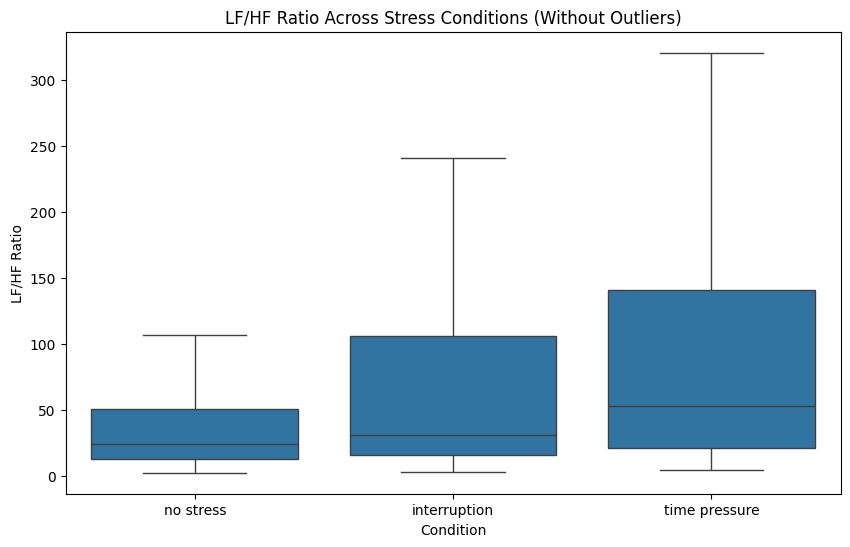

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="condition",
    y="LF_HF",
    showfliers=False
)

plt.title("LF/HF Ratio Across Stress Conditions (Without Outliers)")
plt.xlabel("Condition")
plt.ylabel("LF/HF Ratio")

plt.show()

### LF/HF Ratio Analysis

The LF/HF ratio exhibited higher values and greater variability during time pressure conditions compared to no-stress conditions. This behavior may suggest increased autonomic imbalance and stronger physiological responses during cognitive stress exposure.

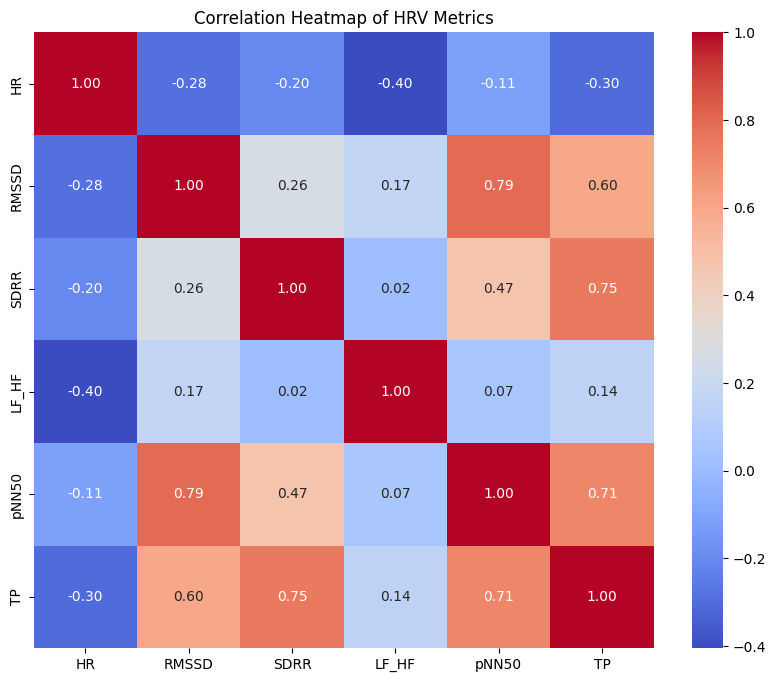

In [9]:
selected_cols = ["HR", "RMSSD", "SDRR", "LF_HF", "pNN50", "TP"]

correlation_matrix = df[selected_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of HRV Metrics")

plt.show()

### Correlation Analysis

Several HRV metrics demonstrated moderate to strong correlations. RMSSD and pNN50 showed a particularly strong positive relationship, which is consistent with their shared association with parasympathetic nervous system activity.

The observed correlations support the physiological consistency of the dataset and highlight meaningful relationships between HRV variables.

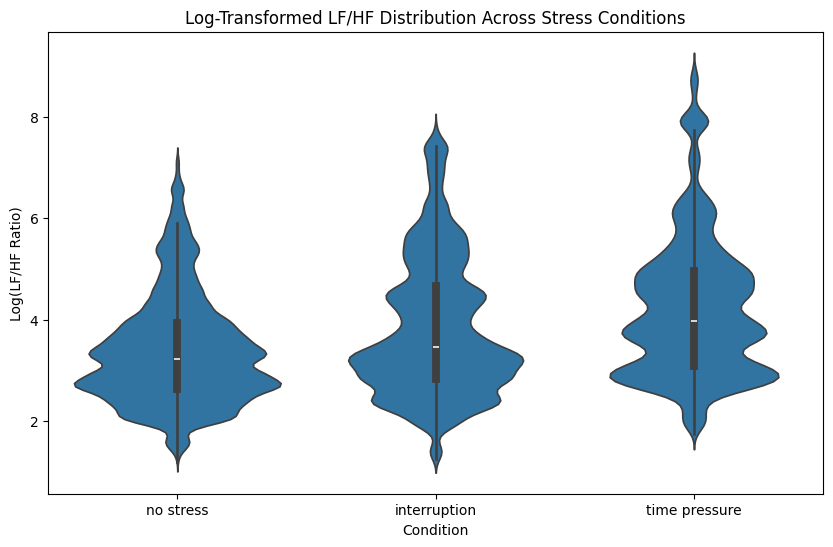

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Crear columna transformada con logaritmo
df["LF_HF_log"] = np.log1p(df["LF_HF"])

# Crear gráfica
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="condition",
    y="LF_HF_log"
)

plt.title("Log-Transformed LF/HF Distribution Across Stress Conditions")
plt.xlabel("Condition")
plt.ylabel("Log(LF/HF Ratio)")

plt.show()

### Distribution Analysis

The log-transformed LF/HF distributions revealed noticeable differences between stress conditions. Time pressure conditions displayed broader distributions and higher density at elevated LF/HF values, suggesting increased physiological variability under cognitive stress.

# 6. Machine Learning Classification

A Random Forest classifier was implemented to evaluate whether HRV metrics could be used to classify physiological stress conditions.

The model was trained using selected HRV features and evaluated on unseen testing data.

In [13]:
#Seleccionar variables
features = ["HR", "RMSSD", "SDRR", "LF_HF", "pNN50", "TP"]

X = df[features]
y = df["condition"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Dividir datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Crear el modelo
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

#Entrenar ML
model.fit(X_train, y_train)

#Predicciones
predictions = model.predict(X_test)

#Evaluar ML
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

               precision    recall  f1-score   support

 interruption       1.00      1.00      1.00     21029
    no stress       1.00      1.00      1.00     40073
time pressure       1.00      1.00      1.00     12756

     accuracy                           1.00     73858
    macro avg       1.00      1.00      1.00     73858
 weighted avg       1.00      1.00      1.00     73858



### Model Performance

The model achieved extremely high classification performance across all stress conditions. These results may indicate strong physiological separability between conditions or specific dataset characteristics that simplify classification.

Further investigation would be required to evaluate potential data leakage and assess real-world generalization.

# 7. Feature Importance Analysis

Feature importance analysis was performed to identify which HRV metrics contributed most significantly to stress condition classification.

Understanding the relative contribution of physiological variables may support the development of interpretable AI-based healthcare systems.

In [14]:
import pandas as pd

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

  Feature  Importance
0      HR    0.235970
1   RMSSD    0.180817
2    SDRR    0.168541
3   LF_HF    0.147957
5      TP    0.144598
4   pNN50    0.122116


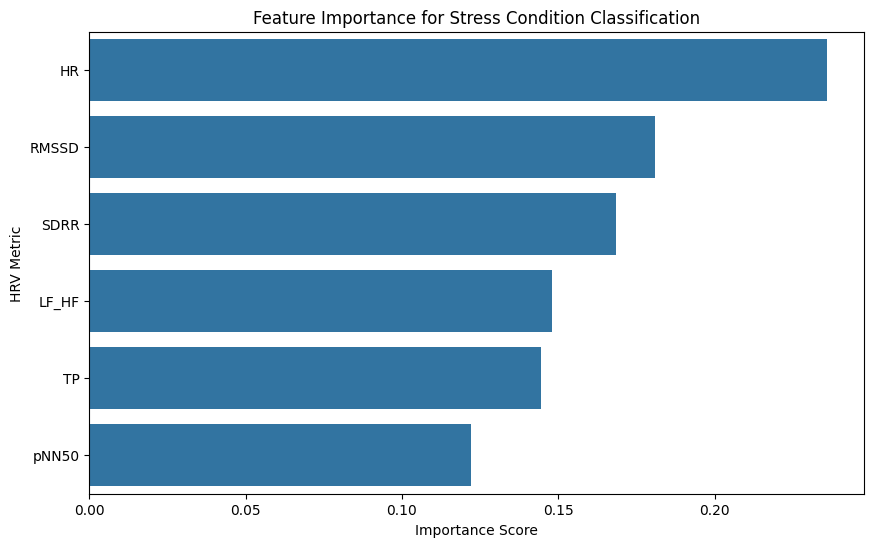

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Stress Condition Classification")
plt.xlabel("Importance Score")
plt.ylabel("HRV Metric")

plt.show()

### Interpretation of Important Features

Heart Rate (HR) was identified as the most influential variable for stress classification, followed by RMSSD and SDRR. These findings are physiologically meaningful, as cardiovascular activity and HRV regulation are closely associated with cognitive stress and autonomic nervous system responses.

# 8. Discussion

The results obtained in this project suggest that cognitive stress conditions produce measurable physiological changes reflected in HRV metrics.

One of the most relevant findings was the increase in LF/HF ratio variability under time pressure conditions. This observation may indicate greater autonomic imbalance and increased sympathetic nervous system activation during cognitive stress exposure, which is consistent with previous HRV research (Pedraza-Rodríguez et al., 2020; Pérez Linares et al., 2023).

Additionally, variables such as Heart Rate (HR), RMSSD, and SDRR demonstrated high relevance during Machine Learning classification. These findings reinforce the physiological importance of cardiovascular regulation and autonomic nervous system activity in stress-related responses.

The correlation analysis also revealed meaningful physiological relationships between HRV metrics, particularly between RMSSD and pNN50, supporting the internal consistency of the dataset and the biomedical relevance of the analyzed variables.

Overall, the results demonstrate the potential of combining biomedical signal analysis and Artificial Intelligence techniques for physiological stress assessment and intelligent healthcare applications.

# 9. Limitations

Although the project achieved highly accurate classification results, several limitations should be considered.

First, the extremely high model performance may suggest strong separability between stress conditions or potential dataset characteristics that simplify classification. Further investigation would be necessary to evaluate possible data leakage and assess real-world generalization.

Additionally, the dataset was collected under controlled experimental conditions, which may not fully represent physiological responses in real-life environments.

Another limitation involves the presence of highly skewed distributions and physiological outliers, which required logarithmic transformations for improved visualization and interpretation.

Finally, this project focused on a limited set of HRV metrics and a single Machine Learning model. Future work could explore additional physiological variables and more advanced AI techniques.

# 10. Conclusions

This project demonstrated the potential of Heart Rate Variability (HRV) metrics for identifying physiological patterns associated with cognitive stress conditions.

Exploratory Data Analysis revealed noticeable differences between no-stress, interruption, and time pressure conditions, particularly in variables such as LF/HF ratio, Heart Rate (HR), RMSSD, and SDRR. These findings suggest that cognitive stress can significantly influence autonomic nervous system behavior.

Machine Learning classification using a Random Forest model achieved extremely high performance when distinguishing physiological states based on HRV metrics. Feature importance analysis identified Heart Rate, RMSSD, and SDRR as the most relevant variables for stress condition classification.

Overall, this project highlights the potential of combining biomedical signal analysis and Artificial Intelligence techniques for future stress monitoring systems, wearable technologies, and intelligent healthcare applications.

# 11. Future Work

Future improvements for this project may include:

- Real-time stress prediction systems
- Integration with wearable devices and smartwatches
- Advanced Machine Learning and Deep Learning models
- Real-world physiological data collection
- Personalized stress monitoring systems
- Parkinson’s disease or neurological disorder analysis using physiological signals

These future developments could contribute to intelligent biomedical monitoring technologies and AI-assisted healthcare systems.

# 12. References

Bratt, C. C. (2020). *Sistema nervioso autónomo desde la perspectiva inmunológica y del estrés*. Revista Pakamuros, 8(4).

Pedraza-Rodríguez, E. M., et al. (2020). *Respuesta autonómica cardiovascular al estrés mental inducido por la prueba de cálculo aritmético*. Revista Cubana de Investigaciones Biomédicas, 39(4).

Pérez Linares, K., et al. (2023). *Variabilidad de la frecuencia cardíaca como biomarcador para la evaluación del estrés*. Revdosdic, 6(2).

SWELL HRV Dataset. (n.d.). Kaggle. Retrieved from https://www.kaggle.com/datasets/qiriro/swell-heart-rate-variability-hrv